### Importing Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import joblib
import mlflow
import mlflow.sklearn
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

### Data Ingestion

In [17]:
filename="/home/naveen/Downloads/data.csv"


data = pd.read_csv(filename, sep=";")

display(data)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


### Data Validation

In [18]:
print(data.shape)

print(data.columns)

print(data.isnull().sum())

print(data.dtypes)

print(data.info())

print(data["Target"].unique())

print(data.duplicated().sum())

print(data["Age at enrollment"].min())
print(data["Age at enrollment"].max())

binary_columns = [
    "Gender",
    "Debtor",
    "Scholarship holder",
    "International",
    "Tuition fees up to date"
]

for col in binary_columns:
    print(f"{col}: {data[col].unique()}")

(4424, 37)
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricula

### EDA

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   
5               2                39                  1    9991   
6               1                 1                  1    9500   
7               1                18                  4    9254   
8               1                 1                  3    9238   
9               1                 1                  1    9238   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1      

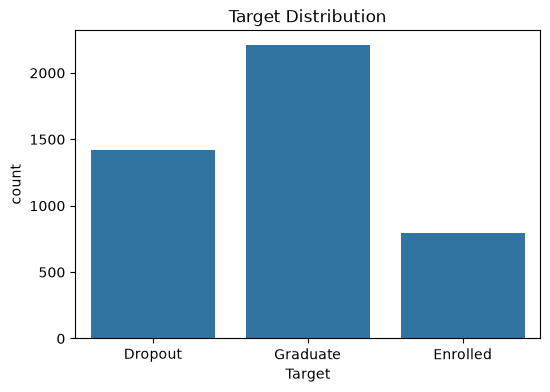

Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


/tmp/ipykernel_6070/1791663746.py:22: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/naveen/Desktop/Student_Dropout/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


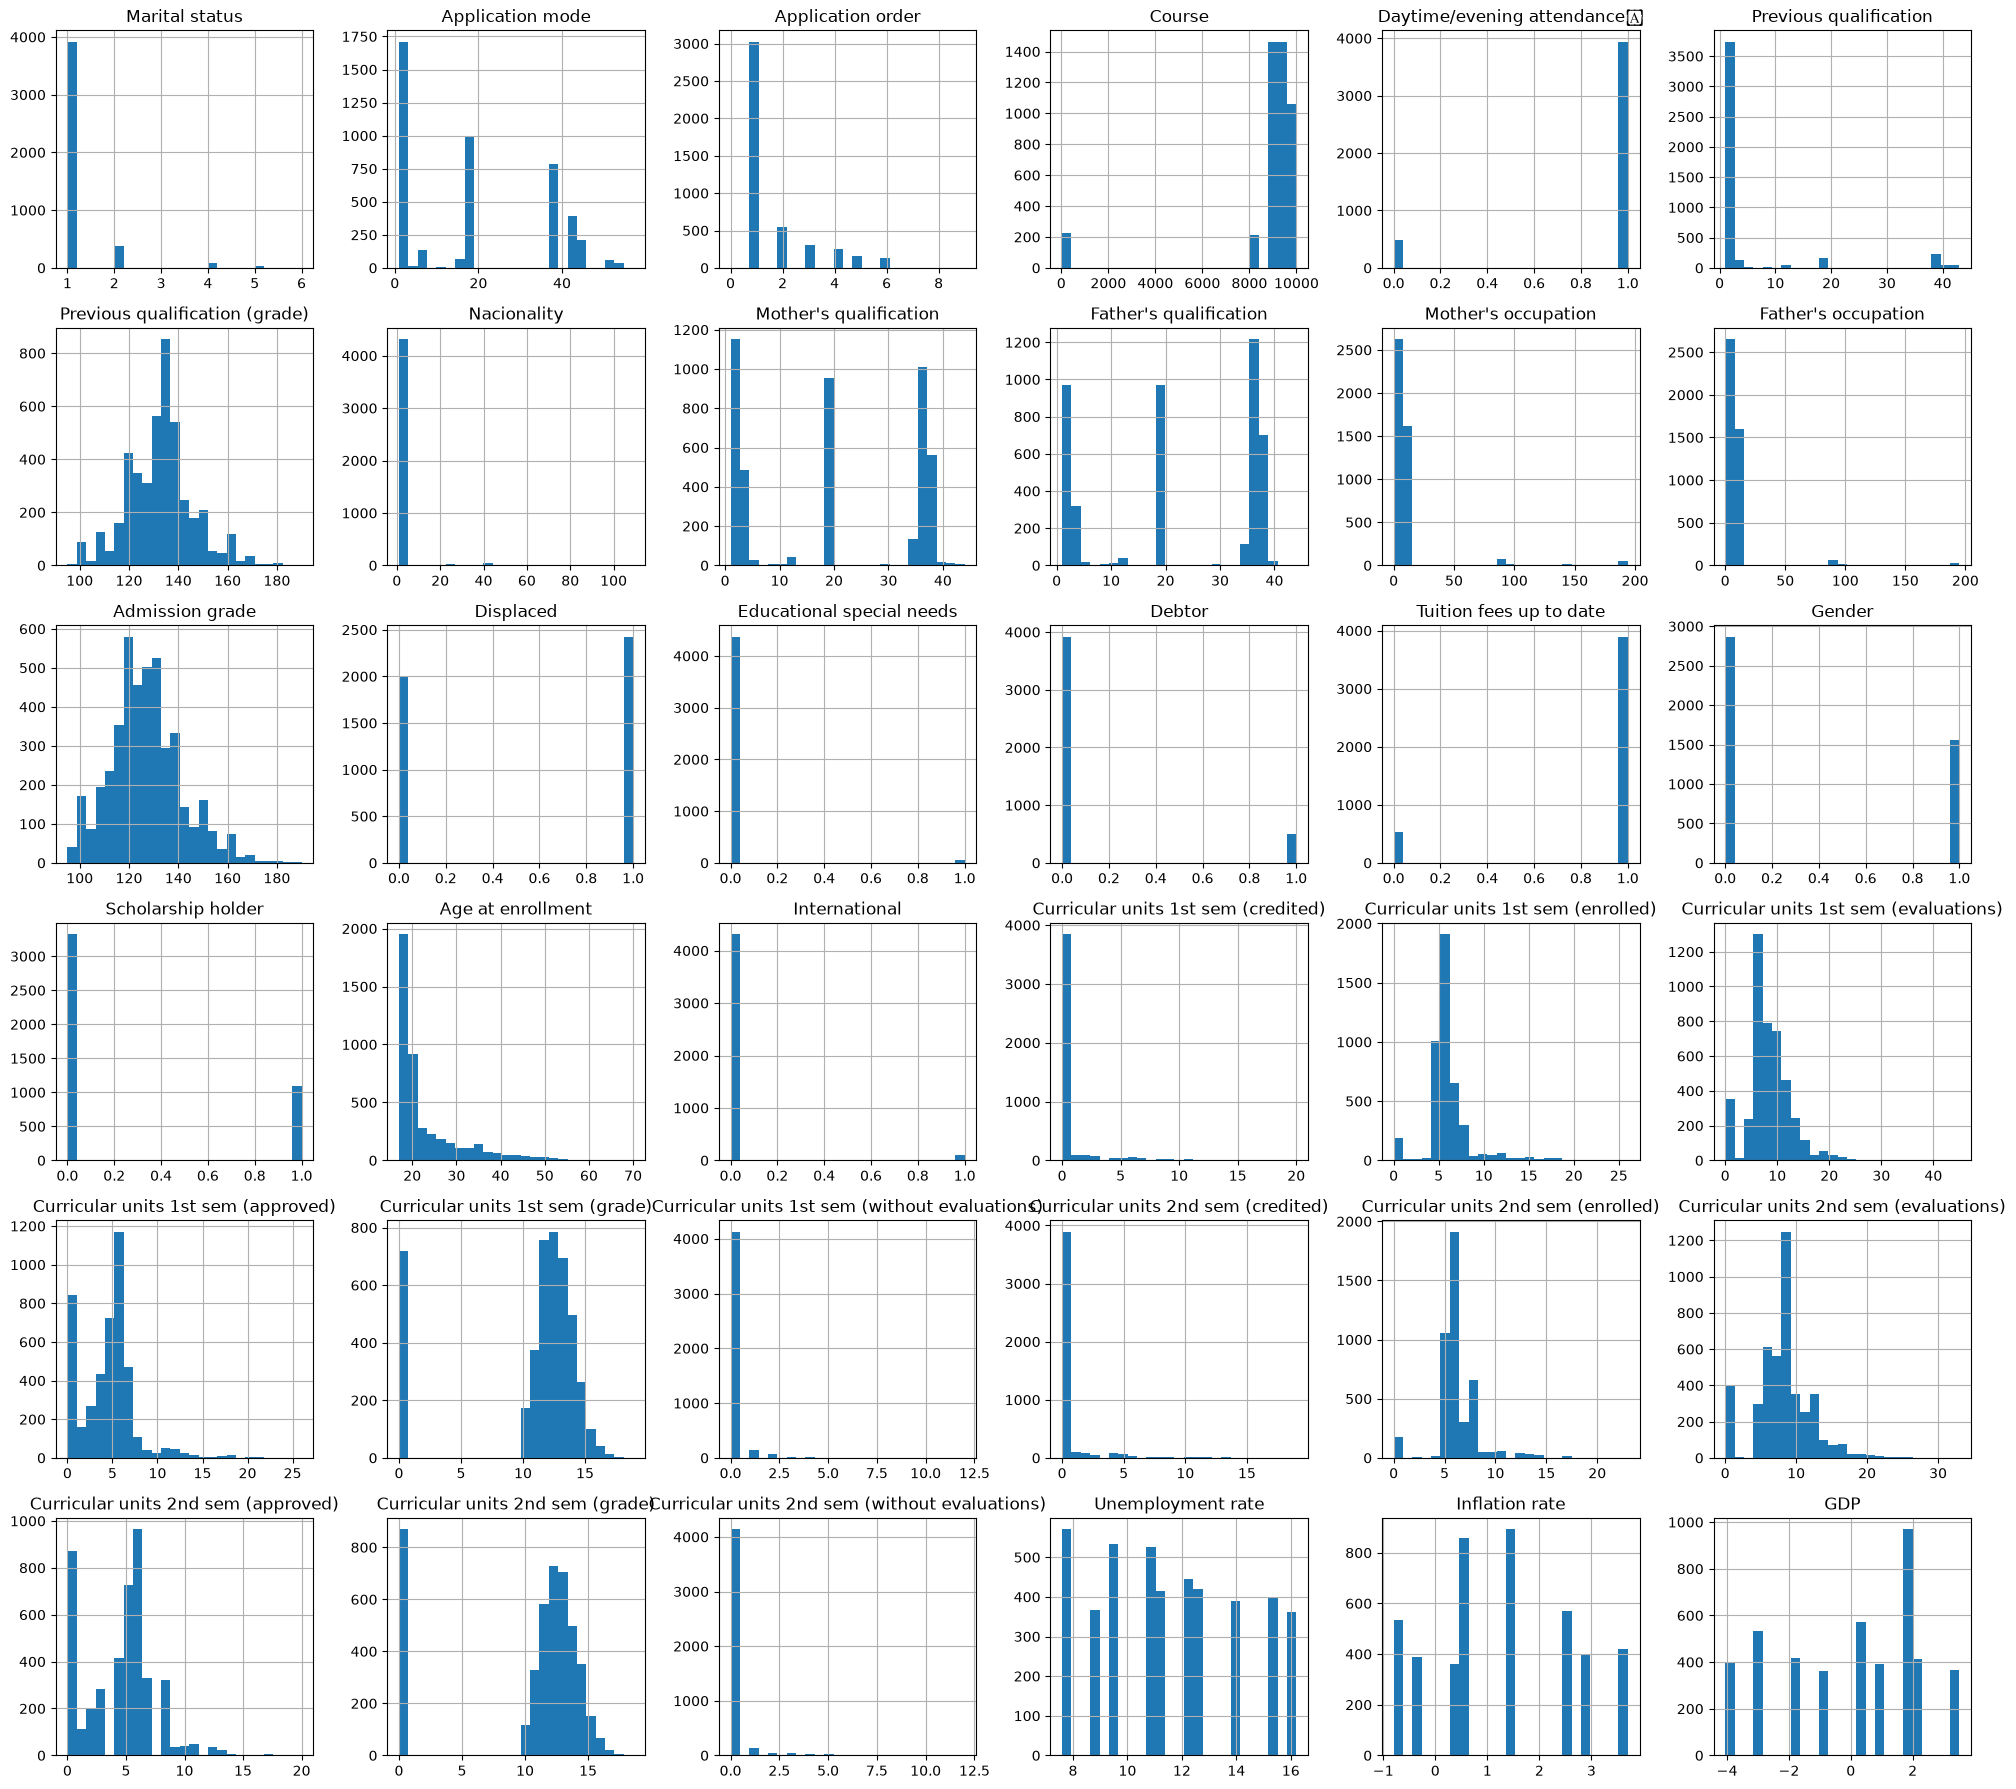

In [19]:
print(data.head(10))

print(data.describe())

data.sample(5)

plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=data)
plt.title("Target Distribution")
plt.show()



target_percent = data["Target"].value_counts(normalize=True)*100

print(target_percent)



data.hist(figsize=(20,18), bins=25)

plt.tight_layout()

plt.show()

### Data Preprocessing

In [20]:
X = data.drop("Target", axis=1)

y = data["Target"]

print(y)
print(X.columns.tolist())

0        Dropout
1       Graduate
2        Dropout
3       Graduate
4       Graduate
          ...   
4419    Graduate
4420     Dropout
4421     Dropout
4422    Graduate
4423    Graduate
Name: Target, Length: 4424, dtype: object
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curr

### Data Scaling adn splitting

In [21]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
)))



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
(3539, 36)
(885, 36)
(3539,)
(885,)


### Model Training

In [22]:
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)


rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)


### Model evaluation

In [23]:
def evaluate_model(y_true, y_pred, model_name):
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted"))
    print("Recall   :", recall_score(y_true, y_pred, average="weighted"))
    print("F1 Score :", f1_score(y_true, y_pred, average="weighted"))

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))


evaluate_model(y_test, log_pred, "Logistic Regression")

evaluate_model(y_test, dt_pred, "Decision Tree")

evaluate_model(y_test, rf_pred, "Random Forest")

evaluate_model(y_test, gb_pred, "Gradient Boosting")


Logistic Regression
Accuracy : 0.768361581920904
Precision: 0.7499810777987659
Recall   : 0.768361581920904
F1 Score : 0.7531276658422533

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.77      0.78       284
           1       0.52      0.33      0.41       159
           2       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885

Decision Tree
Accuracy : 0.6971751412429379
Precision: 0.7019027402107435
Recall   : 0.6971751412429379
F1 Score : 0.6994161024346667

Classification Report

              precision    recall  f1-score   support

           0       0.70      0.70      0.70       284
           1       0.40      0.43      0.41       159
           2       0.81      0.79      0.80       442

    accuracy                           0.70       885
   macro avg       0.64    

### Model Tuning

In [24]:

log_model = LogisticRegression()

# Hyperparameter Grid
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [100, 500, 1000]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
grid_search.fit(X_train_scaled, y_train)

# Best Model
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}

Best Cross Validation Accuracy:
0.7651875114872262


/home/naveen/Desktop/Student_Dropout/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
75 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/home/naveen/Desktop/Student_Dropout/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/naveen/Desktop/Student_Dropout/venv/lib/python3.13/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/naveen/Desktop/Stude

### Save model

In [25]:
joblib.dump(best_model, "logistic_regression_model.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [26]:

sample = X_test.iloc[[0]]


sample_scaled = scaler.transform(sample)


prediction = best_model.predict(sample_scaled)


predicted_class = label_encoder.inverse_transform(prediction)

print("Encoded Prediction :", prediction[0])
print("Predicted Class    :", predicted_class[0])

Encoded Prediction : 2
Predicted Class    : Graduate


In [27]:

actual_encoded = y_test[0]


actual_class = label_encoder.inverse_transform([actual_encoded])

print("Actual Class       :", actual_class[0])
print("Predicted Class    :", predicted_class[0])

Actual Class       : Graduate
Predicted Class    : Graduate


In [28]:
import mlflow

print(mlflow.__version__)


3.14.0


In [29]:
mlflow.set_experiment("Student Dropout Prediction")

print("Experiment created successfully!")

2026/07/07 05:08:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/07 05:08:16 INFO mlflow.store.db.utils: Updating database tables
2026/07/07 05:08:17 INFO mlflow.tracking.fluent: Experiment with name 'Student Dropout Prediction' does not exist. Creating a new experiment.


Experiment created successfully!


In [30]:
experiment = mlflow.get_experiment_by_name("Student Dropout Prediction")

print(experiment)

<Experiment: artifact_location='/home/naveen/Desktop/Student_Dropout/notebook/mlruns/1', creation_time=1783377497526, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783377497526, lifecycle_stage='active', name='Student Dropout Prediction', tags={}, trace_location=None, workspace='default'>


In [31]:
y_pred = log_model.predict(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

with mlflow.start_run():

    # Parameters
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("random_state", 42)

    # Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Model
    mlflow.sklearn.log_model(
        sk_model=log_model,
        name="logistic_regression_model"
    )

print("Experiment Logged Successfully!")


NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.